In [114]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi
import sympy as sp

FLOAT32 = np.float32

In [115]:

# ============================
# Parameters
# ============================

SECONDS_PER_YEAR = FLOAT32(365 * 24 * 3600)
### anthropogenic emissions ###
A_tot = FLOAT32(5000.0)   # GtC, total carbon emitted
t_opt = FLOAT32(150.0)    # yr, t_opt for RCP8.5

t = sp.symbols("t", real=True)

# Cumulative emissions A(t)
A = A_tot * (
    1 / (1 + 2.5 * sp.exp((t_opt - t) / 50))
    - 1 / (1 + 2.5 * sp.exp(t_opt / 50))
)

# Emission rate J(t) = dA/dt
J = sp.diff(A, t)
# define instantaneous emission rate function J(t) as a function of time t

# Fast numerical functions
A_func = sp.lambdify(t, A, "numpy")
J_func = sp.lambdify(t, J, "numpy")

### inital Temperature ###
Ts_init = FLOAT32(0.0)      # K, initial surface temperature
Td_init = FLOAT32(0.0)      # K, initial deep ocean temperature
lam_star = FLOAT32(0.75)       # W m^-2 K^-1, heat transfer coefficient
lam = FLOAT32(1.75)         # W m^-2 K^-1, climate feedback parameter
beta = FLOAT32(5.35)        # W m^-2 K^-1, CO2 forcing parameter


### Heat capacities ###
surface_depth = FLOAT32(50.0)
deep_depth = FLOAT32(3000.0)
c_s = FLOAT32(4000.0) * surface_depth * FLOAT32(1000.0)      # J m^-2 K^-1
c_d = FLOAT32(4000.0) * deep_depth * FLOAT32(1000.0)       # J m^-2 K^-1
c_star = c_s + c_d                     # J m^-2 K^-1

### atmospheric carbon ###
k_a  = FLOAT32(2.12)          # CO2 scaling constant
Ca_init = FLOAT32(600.0)         # GtC, pre-industrial atmospheric carbon
P_a0 = Ca_init / k_a    # ppm, pre-industrial atmospheric CO2

etaH = FLOAT32(0.7)         # W m^-2 K^-1, heat transfer coefficient

### land carbon ###
beta_pi = FLOAT32(0.4)     # CO2 fertilization factor
chi     = FLOAT32(1.8)     # scaling constant
tau_l0   = FLOAT32(41.0)    # yr, lifetime of land carbon
Pi_0    = FLOAT32(60.0)    # GtC/yr, preindustrial land flux
Cl_init    = FLOAT32(2460.0)  # GtC, preindustrial land carbon

### ocean carbon cycle ###
D     = surface_depth + deep_depth     # m, average ocean depth
delta = surface_depth / D    # fraction (mixed-layer depth / D)
gamma = FLOAT32(0.02)        # GtC/yr/ppm, air-sea transfer coefficient
mu_0  = FLOAT32(5.0)        # buffer constant (m/year)
zeta  = 6#10.5        # ratio between ocean reservoirs and atmosphere
etaC = mu_0/D       # transfer rate by total depth

# C_s0 + C_d0 = 6 * zeta * C_a0
# C_s0 / C_d0 = delta / (1 - delta)
# => solve the two simultaneous equations for C_s0, C_d0

total_sd = FLOAT32(6.0) * zeta * Ca_init   # GtC, total preindustrial ocean carbon
Cd_init = (FLOAT32(1.0)-delta) * total_sd   # GtC, preindustrial deep ocean carbon

Cs_init = total_sd - Cd_init               # GtC, preindustrial surface ocean carbon

kappa_o = FLOAT32(6.0) * k_a * delta   # ocean CO2 uptake constant


def box_rhs(t, y, scenario=1):
    """
    scenario=1: anthropogenic emissions J enter the atmosphere (dCa)
    scenario=2: anthropogenic emissions J enter the deep ocean (dCd)
    """
    t = FLOAT32(t)
    Ts, Td, Cs, Cd, Ca, Cl = np.asarray(y, dtype=FLOAT32)

    ### Anthropogenic emissions ###
    J = FLOAT32(J_func(t))  # GtC/seconds

    ### Temperature evolution surface and deep ###
    forcing = beta * np.log(Ca / Ca_init + FLOAT32(1.0))

    dTs = FLOAT32(
        ((-lam * Ts
        + forcing
        - (etaH + lam_star) * (Ts - Td))
        * SECONDS_PER_YEAR
        / (delta * c_star))
    )

    dTd = FLOAT32(
        (etaH * (Ts - Td)
        * SECONDS_PER_YEAR
        / ((FLOAT32(1.0)-delta) * c_star))
    )

    ### Land carbon evolution ###

    dCl = FLOAT32(
        Pi_0 * (FLOAT32(1.0) + beta_pi * np.log((Ca / Ca_init) + FLOAT32(1.0)))
        - ((Cl + Cl_init) / tau_l0) * chi ** (Ts / FLOAT32(10.0))
    )

    ### Surface ocean carbon evolution ###

    ko = k_a / zeta * (Cs_init / Ca_init)

    dCs = FLOAT32(gamma * (Ca / k_a - Cs / ko) - etaC * (Cs / delta - Cd / (FLOAT32(1.0)-delta)))

    ### Deep ocean carbon evolution ###

    dCd = FLOAT32(etaC * (Cs / delta - Cd / (FLOAT32(1.0)-delta)))

    ### Atmosphere carbon evolution ###

    dCa = FLOAT32(-dCs - dCl - dCd)

    if scenario == 1:
        # J enters the atmosphere
        dCa = FLOAT32(J - dCs - dCl - dCd)
    elif scenario == 2:
        # J enters the deep ocean
        dCd = FLOAT32(dCd + J)
    elif scenario == 3:
        # J enters the surface ocean
        dCs = FLOAT32(dCs + J)
    elif scenario == 4:
        # J enters the land
        dCl = FLOAT32(dCl + J)

    return [dTs, dTd, dCs, dCd, dCa, dCl]


In [116]:
y_box = [FLOAT32(0.0), FLOAT32(0.0), FLOAT32(0.0), FLOAT32(0.0), FLOAT32(0.0), FLOAT32(0.0)]
t = np.arange(FLOAT32(0.0), FLOAT32(10000.0), FLOAT32(1.0), dtype=FLOAT32) # time in seconds

forcing = FLOAT32(0.0)
solver_kwargs = dict(method='RK45', t_eval=t, rtol=1e-8, atol=1e-10)

# Scenario 1: J enters the atmosphere (dCa)
y_box = [FLOAT32(0.0), FLOAT32(0.0), FLOAT32(0.0), FLOAT32(0.0), forcing, FLOAT32(0.0)]
sol_box_s1 = spi.solve_ivp(
    lambda t, y: box_rhs(t, y, scenario=1),
    (t[0], t[-1]),
    y_box,
    **solver_kwargs
)

# Scenario 2: J enters the deep ocean (dCd)
y_box = [FLOAT32(0.0), FLOAT32(0.0), FLOAT32(0.0), forcing, FLOAT32(0.0), FLOAT32(0.0)]
sol_box_s2 = spi.solve_ivp(
    lambda t, y: box_rhs(t, y, scenario=2),
    (t[0], t[-1]),
    y_box,
    **solver_kwargs
)

# Scenario 3: J enters the surface ocean (dCs)
y_box = [FLOAT32(0.0), FLOAT32(0.0), forcing, FLOAT32(0.0), FLOAT32(0.0), FLOAT32(0.0)]
sol_box_s3 = spi.solve_ivp(
    lambda t, y: box_rhs(t, y, scenario=3),
    (t[0], t[-1]),
    y_box,
    **solver_kwargs
)

# Scenario 4: J enters the land (dCl)
y_box = [FLOAT32(0.0), FLOAT32(0.0), FLOAT32(0.0), FLOAT32(0.0), FLOAT32(0.0), forcing]
sol_box_s4 = spi.solve_ivp(
    lambda t, y: box_rhs(t, y, scenario=4),
    (t[0], t[-1]),
    y_box,
    **solver_kwargs
)


In [117]:

def find_equilibrium_time(t, gradient, tolerance=FLOAT32(1e-3)):
    """
    Finds the first value from behind where the gradient is more than the tolerance
    and then returns the corresponding time. If no such value is found, returns None.
    """
    t = np.asarray(t, dtype=FLOAT32)
    gradient = np.asarray(gradient, dtype=FLOAT32)
    for i in range(len(gradient) - 1, -1, -1):
        if abs(gradient[i]) > tolerance:
            return t[i]  # return time in years
    return None

# Compute gradients (dy/dt) by re-evaluating box_rhs at each stored time step.
# This gives exact ODE derivatives, shape (6, N), matching sol.y.
def compute_gradients(sol, scenario):
    grads = np.array(
        [box_rhs(ti, yi, scenario=scenario) for ti, yi in zip(sol.t, sol.y.T)],
        dtype=FLOAT32,
    )
    return grads.T  # shape: (n_vars, n_timepoints)

grad_s1 = compute_gradients(sol_box_s1, scenario=1)
grad_s2 = compute_gradients(sol_box_s2, scenario=2)
grad_s3 = compute_gradients(sol_box_s3, scenario=3)
grad_s4 = compute_gradients(sol_box_s4, scenario=4)

find_equilibrium_time(t, grad_s1[2], tolerance=FLOAT32(1e-3))


np.float32(1664.0)

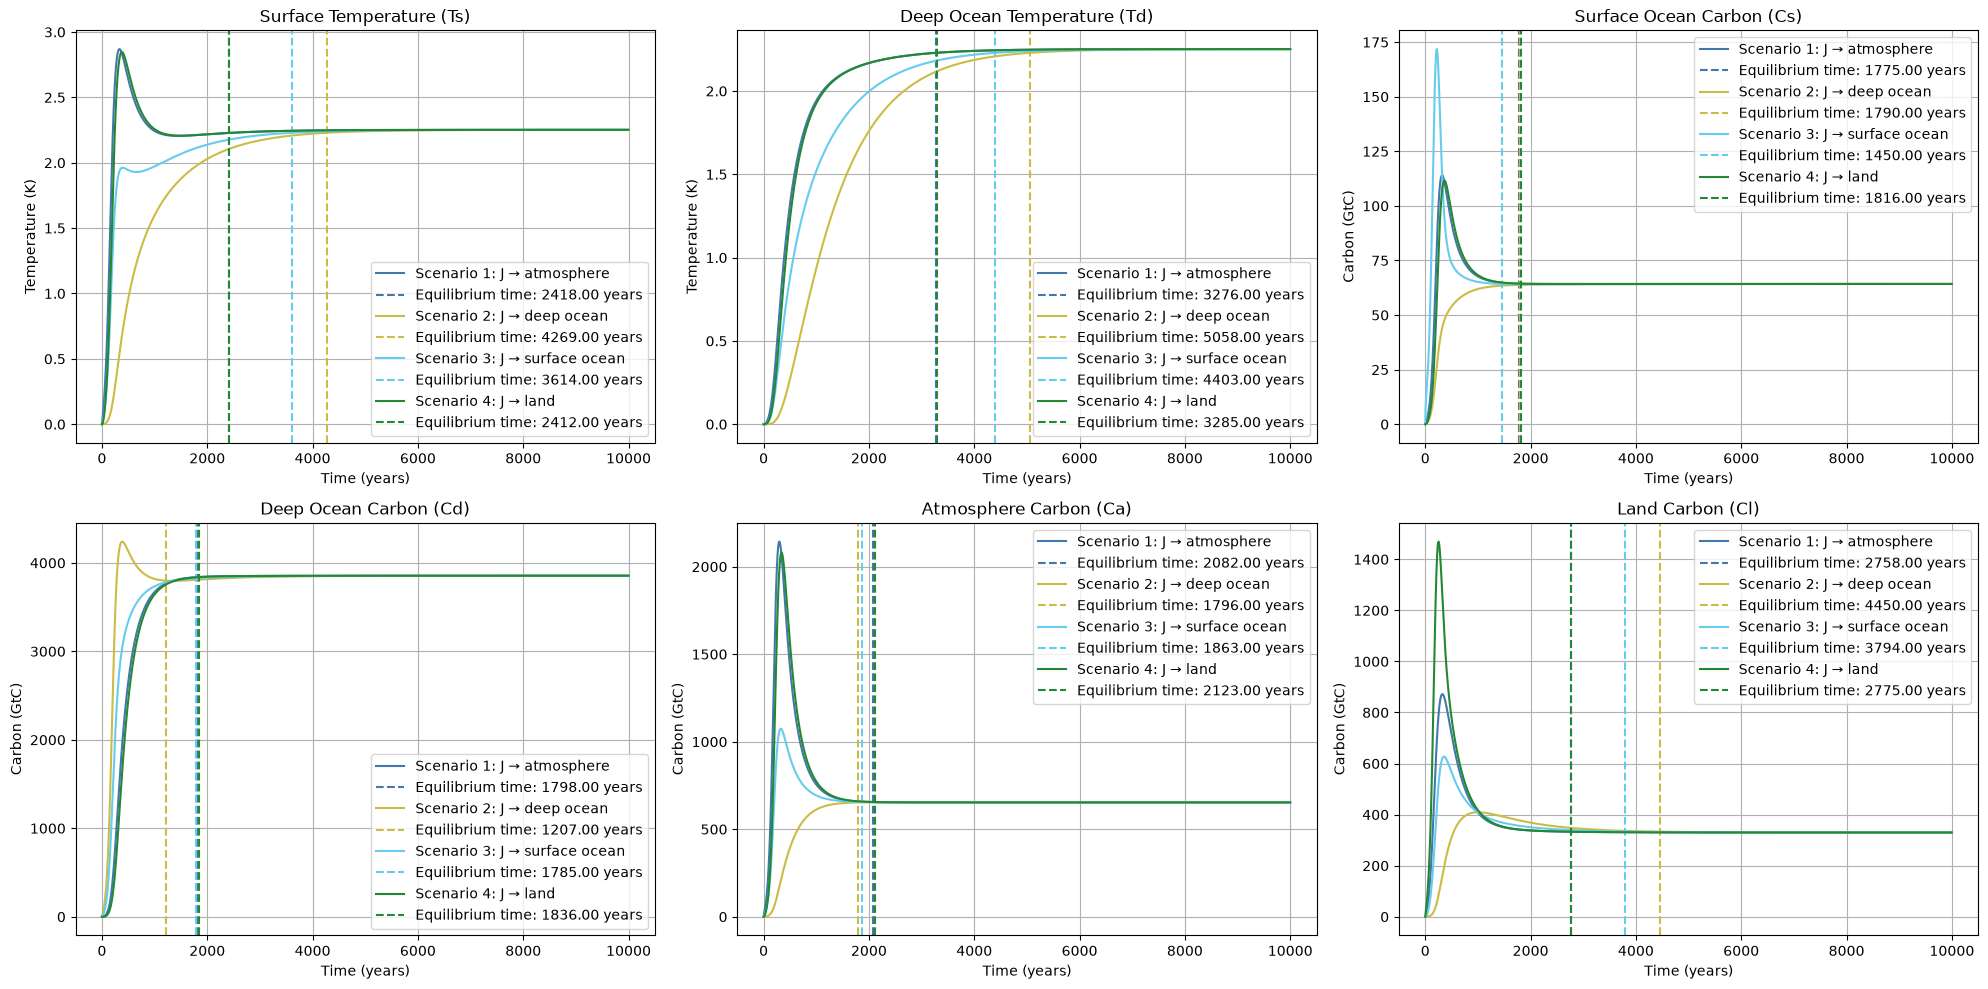

In [118]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
axs = axs.flatten()

titles = [
    'Surface Temperature (Ts)', 'Deep Ocean Temperature (Td)',
    'Surface Ocean Carbon (Cs)', 'Deep Ocean Carbon (Cd)',
    'Atmosphere Carbon (Ca)', 'Land Carbon (Cl)'
]
ylabels = ['Temperature (K)', 'Temperature (K)', 'Carbon (GtC)', 'Carbon (GtC)', 'Carbon (GtC)', 'Carbon (GtC)']

time32 = np.asarray(t, dtype=FLOAT32)

for sol, grad, color, label in [
    (sol_box_s1, grad_s1, '#4477AA',  'Scenario 1: J → atmosphere'),
    (sol_box_s2, grad_s2, '#CCBB44', 'Scenario 2: J → deep ocean'),
    (sol_box_s3, grad_s3, "#66CCEE", 'Scenario 3: J → surface ocean'),
    (sol_box_s4, grad_s4, '#228833', 'Scenario 4: J → land')
]:
    sol_t = np.asarray(sol.t, dtype=FLOAT32)
    sol_y = np.asarray(sol.y, dtype=FLOAT32)
    for i in range(sol_y.shape[0]):
        axs[i].plot(sol_t, sol_y[i], label=label, color=color)
        final_value = np.cumsum(np.asarray(grad[i], dtype=FLOAT32), dtype=FLOAT32)[-1]  # Get the final value of the cumulative sum
        equlibrium_time = find_equilibrium_time(sol_t, grad[i], tolerance=FLOAT32(final_value * FLOAT32(1e-5)))  # Adjust tolerance based on final value
        if equlibrium_time is not None:
            axs[i].axvline(x=equlibrium_time, color=color, linestyle='--', label=f'Equilibrium time: {equlibrium_time:.2f} years')

for i, ax in enumerate(axs):
    ax.set_xlabel('Time (years)')
    ax.set_ylabel(ylabels[i])
    ax.set_title(titles[i])
    ax.grid()
    ax.legend()

plt.tight_layout()


In [119]:
np.cumsum(np.asarray(grad_s1[0], dtype=FLOAT32), dtype=FLOAT32)

array([0.0000000e+00, 2.0789804e-03, 5.3593991e-03, ..., 2.2514129e+00,
       2.2514129e+00, 2.2514129e+00], shape=(10000,), dtype=float32)

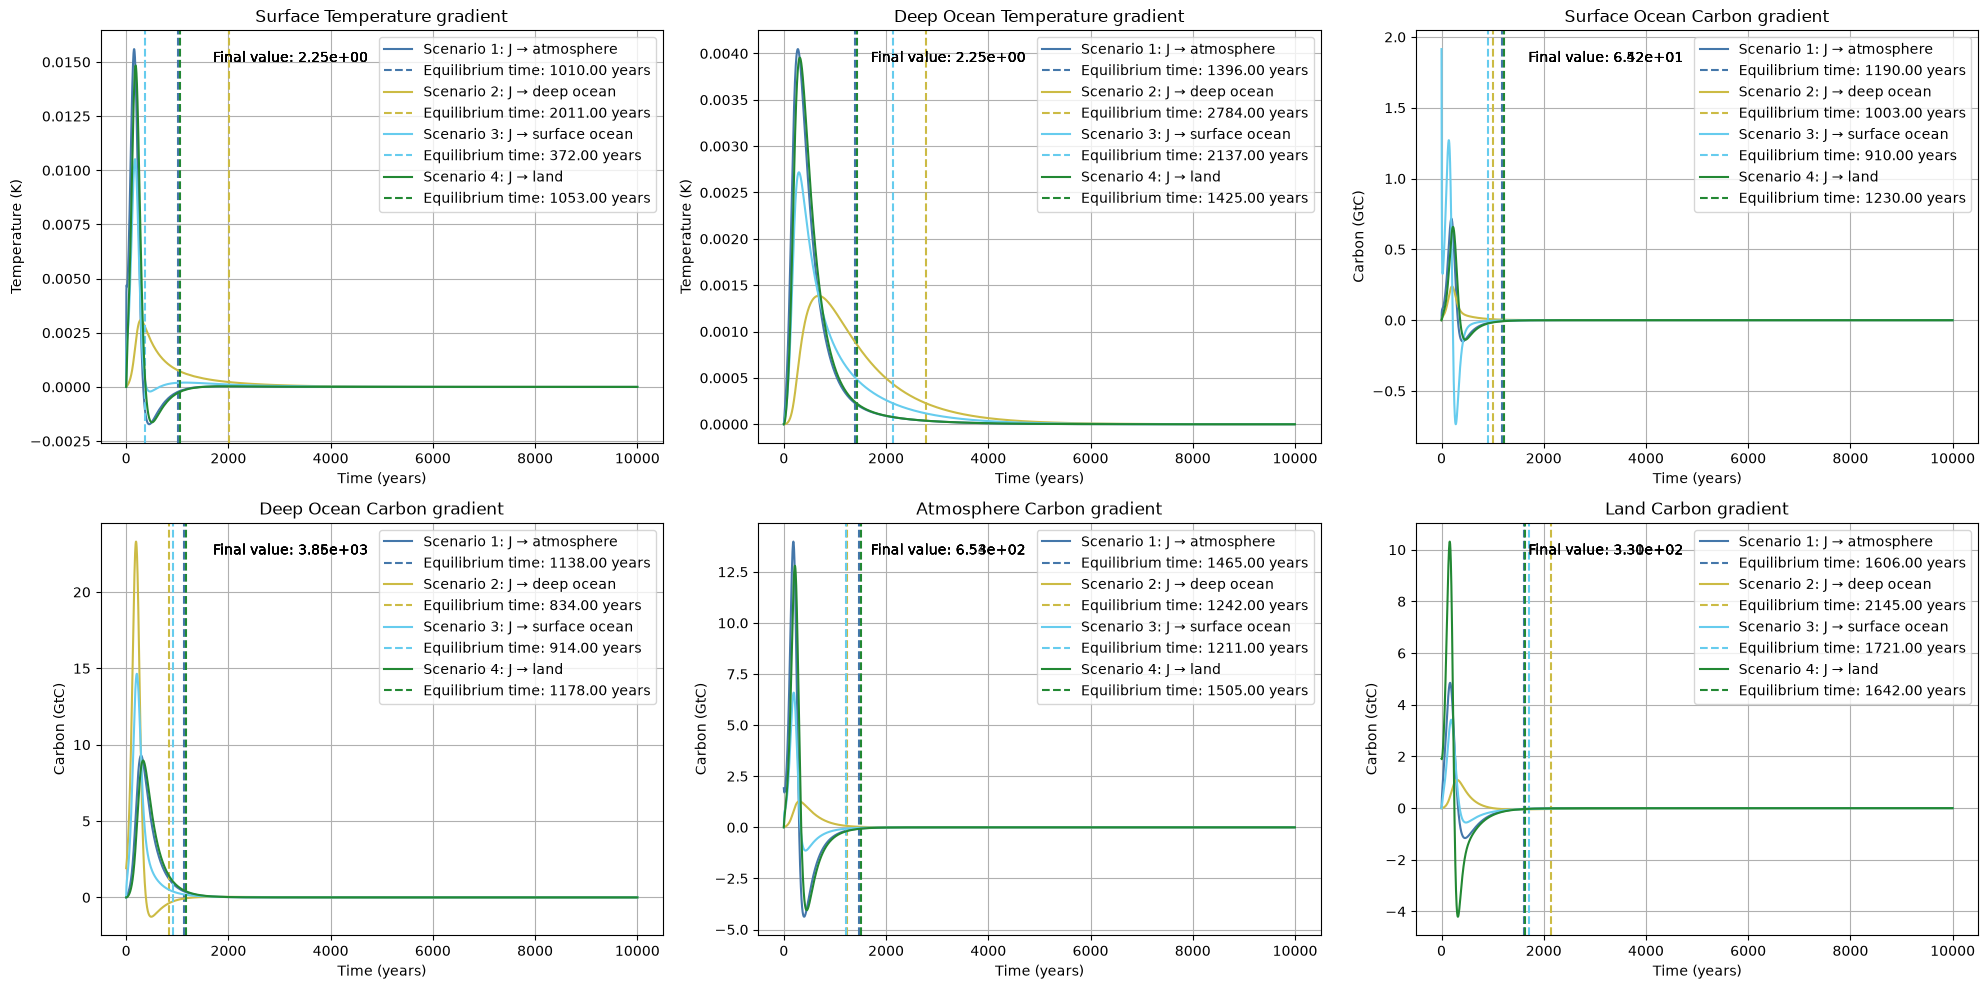

In [120]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
axs = axs.flatten()

titles = [
    'Surface Temperature gradient', 'Deep Ocean Temperature gradient',
    'Surface Ocean Carbon gradient', 'Deep Ocean Carbon gradient',
    'Atmosphere Carbon gradient', 'Land Carbon gradient'
]
ylabels = ['Temperature (K)', 'Temperature (K)', 'Carbon (GtC)', 'Carbon (GtC)', 'Carbon (GtC)', 'Carbon (GtC)']

time32 = np.asarray(t, dtype=FLOAT32)

for sol, grad, color, label in [
    (sol_box_s1, grad_s1, '#4477AA',  'Scenario 1: J → atmosphere'),
    (sol_box_s2, grad_s2, '#CCBB44', 'Scenario 2: J → deep ocean'),
    (sol_box_s3, grad_s3, "#66CCEE", 'Scenario 3: J → surface ocean'),
    (sol_box_s4, grad_s4, '#228833', 'Scenario 4: J → land')
]:
    sol_t = np.asarray(sol.t, dtype=FLOAT32)
    grad32 = np.asarray(grad, dtype=FLOAT32)
    for i in range(grad32.shape[0]):
        axs[i].plot(sol_t, grad32[i], label=label, color=color)
        final_value = np.cumsum(grad32[i], dtype=FLOAT32)[-1]  # Get the final value of the cumulative sum
        axs[i].text(0.2, 0.95, f'Final value: {final_value:.2e}', transform=axs[i].transAxes, verticalalignment='top')
        equlibrium_time = find_equilibrium_time(sol_t, grad32[i], tolerance=FLOAT32(final_value * FLOAT32(1e-4)))  # Adjust tolerance based on final value
        if equlibrium_time is not None:
            axs[i].axvline(x=equlibrium_time, color=color, linestyle='--', label=f'Equilibrium time: {equlibrium_time:.2f} years')
            #axs[i].text(equlibrium_time, axs[i].get_ylim()[1]*0.9, f'{equlibrium_time:.2f} yrs', rotation=90, verticalalignment='top')
for i, ax in enumerate(axs):
    ax.set_xlabel('Time (years)')
    ax.set_ylabel(ylabels[i])
    ax.set_title(titles[i])
    ax.grid()
    ax.legend()

plt.tight_layout()


In [128]:
def calc_A(t, t_opt, A_tot):
    """
    Calculate cumulative emissions A(t) based on the given parameters.
    """
    return A_tot * (
        1 / (1 + 2.5 * np.exp((t_opt - t) / 50))
        - 1 / (1 + 2.5 * np.exp(t_opt / 50))
    )

In [138]:
t = np.arange(0, 10000, 1, dtype=FLOAT32)
A_tot = FLOAT32(5000.0)
t_opt = np.arange(0, 2000, 100, dtype=FLOAT32)


Text(0, 0.5, 'Cumulative Emissions A(t) (GtC)')

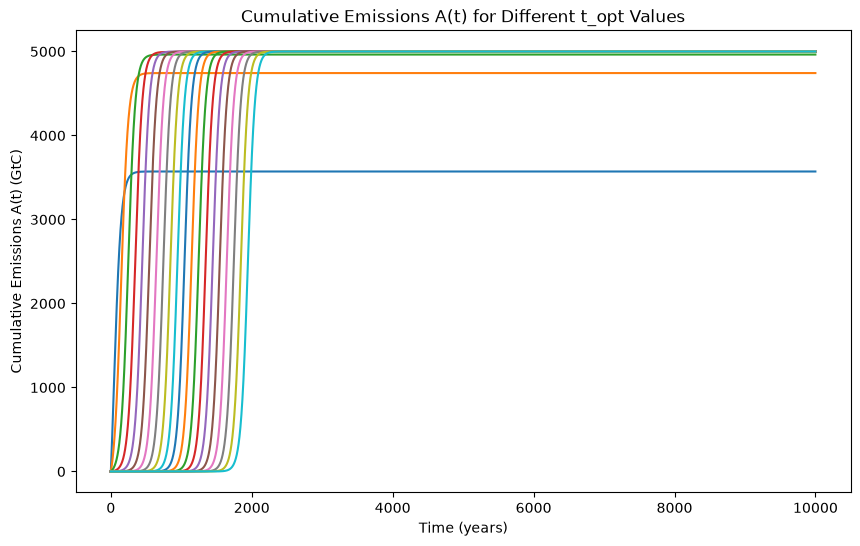

In [139]:
plt.figure(figsize=(10, 6))
for t_opt_value in t_opt:
    A_values = calc_A(t, t_opt_value, A_tot)
    plt.plot(t, A_values, label=f't_opt={t_opt_value} years')
plt.title('Cumulative Emissions A(t) for Different t_opt Values')
plt.xlabel('Time (years)')
plt.ylabel('Cumulative Emissions A(t) (GtC)')

In [148]:
t = np.arange(0, 10000, 1, dtype=FLOAT32)
A_tot = np.arange(1000, 7001, 1000, dtype=FLOAT32)#FLOAT32(5000.0)
t_opt = FLOAT32(250.0)#np.arange(0, 2000, 100, dtype=FLOAT32)

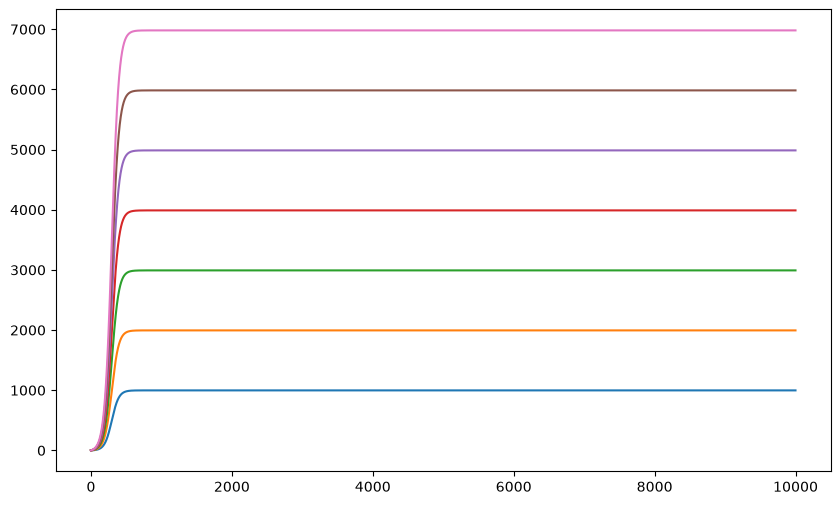

In [149]:
plt.figure(figsize=(10, 6))
for A_tot_value in A_tot:
    A_values = calc_A(t, t_opt, A_tot_value)
    plt.plot(t, A_values, label=f't_opt={t_opt_value} years')